<h1>Module 16 Project Template</h1>

Use the code below to help you analyze the data returned by the MBTA API:

In [1]:
mbtaURL = "https://api-v3.mbta.com/vehicles?filter[route]=1&include=trip"

import urllib.request, json
with urllib.request.urlopen(mbtaURL) as url:
    data = json.loads(url.read().decode())
   
    with open('data.json', 'w') as outfile:
        json.dump(data, outfile)
   
    with open('data.txt', 'w') as outfile:
        json.dump(json.dumps(data, indent=4, sort_keys=True), outfile)
       
    print(json.dumps(data, indent=4, sort_keys=True))


{
    "data": [
        {
            "attributes": {
                "bearing": null,
                "carriages": [],
                "current_status": "STOPPED_AT",
                "current_stop_sequence": 7,
                "direction_id": 0,
                "label": "1919",
                "latitude": 42.334671,
                "longitude": -71.074814,
                "occupancy_status": null,
                "revenue": "REVENUE",
                "speed": null,
                "updated_at": "2026-04-20T23:26:07-04:00"
            },
            "id": "y1919",
            "links": {
                "self": "/vehicles/y1919"
            },
            "relationships": {
                "route": {
                    "data": {
                        "id": "1",
                        "type": "route"
                    }
                },
                "stop": {
                    "data": {
                        "id": "58",
                        "type": "stop"
              

Use the code below to read the data from your MySQL database and store it in a pandas dataframe.  

You you need to install pymysql to run the code:

pip install pymysql

In [ ]:
import os
import pymysql
import pandas as pd

host = '127.0.0.1'
port = '3307'
user = 'root'
password = os.getenv("MYSQL_PASSWORD", "YOUR_MYSQL_PASSWORD")
database = 'MBTAdb'

conn = pymysql.connect(
    host=host,
    port=int(3307),
    user="root",
    passwd=password,
    db=database,
    charset='utf8mb4')

df = pd.read_sql_query("SELECT * FROM mbta_buses",
    conn)

df.tail(10)

C:\Users\bgeet\AppData\Local\Temp\ipykernel_75872\367500402.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query("SELECT * FROM mbta_buses",


,record_num,id,label,latitude,longitude,bearing,direction_id,current_status,occupancy_status,stop_id,trip_id,current_stop_sequence,updated_at
21351,21352,y1899,1899,42.372950,-71.117130,270.0,1,STOPPED_AT,MANY_SEATS_AVAILABLE,110,75342703,1,2026-04-21 03:31:42
21352,21353,y1867,1867,42.360927,-71.096392,103.0,1,IN_TRANSIT_TO,MANY_SEATS_AVAILABLE,74,75342699,9,2026-04-21 03:31:45
21353,21354,y1817,1817,42.329820,-71.083540,90.0,0,STOPPED_AT,MANY_SEATS_AVAILABLE,64,75342925,1,2026-04-21 03:31:45
21354,21355,y1750,1750,42.365340,-71.103434,309.0,0,STOPPED_AT,MANY_SEATS_AVAILABLE,102,75342668,18,2026-04-21 03:31:42
21355,21356,y1919,1919,42.342260,-71.084138,311.0,0,STOPPED_AT,NaN,89,75342664,11,2026-04-21 03:31:50
21356,21357,y1900,1900,42.329985,-71.083837,NaN,0,STOPPED_AT,MANY_SEATS_AVAILABLE,64,75342672,1,2026-04-21 03:29:33
21357,21358,y1899,1899,42.372950,-71.117130,270.0,1,STOPPED_AT,MANY_SEATS_AVAILABLE,110,75342703,1,2026-04-21 03:31:42
21358,21359,y1867,1867,42.360911,-71.096440,NaN,1,STOPPED_AT,MANY_SEATS_AVAILABLE,74,75342699,9,2026-04-21 03:31:56
21359,21360,y1817,1817,42.329820,-71.083540,90.0,0,STOPPED_AT,MANY_SEATS_AVAILABLE,64,75342925,1,2026-04-21 03:31:45
21360,21361,y1750,1750,42.365379,-71.103444,NaN,0,STOPPED_AT,MANY_SEATS_AVAILABLE,102,75342668,18,2026-04-21 03:31:58


pymysql working in Jupyter



The code below saves the data as a csv file to the local directory as a backup.

In [3]:

df.to_csv('mbta.csv')

<h1>What is the average time it takes for a bus to complete the route</h1>

In [18]:
df['updated_at'] = pd.to_datetime(df['updated_at']) 

route_time = df.groupby('trip_id').agg(
    start_time=('updated_at', 'min'),
    end_time=('updated_at', 'max')
)

route_time['duration_minutes'] = (
    route_time['end_time'] - route_time['start_time']
).dt.total_seconds() / 60

avg_time = route_time['duration_minutes'].mean()
print(avg_time)

34.237905604719764


<h1>Provide a Visualization based on the data</h1>

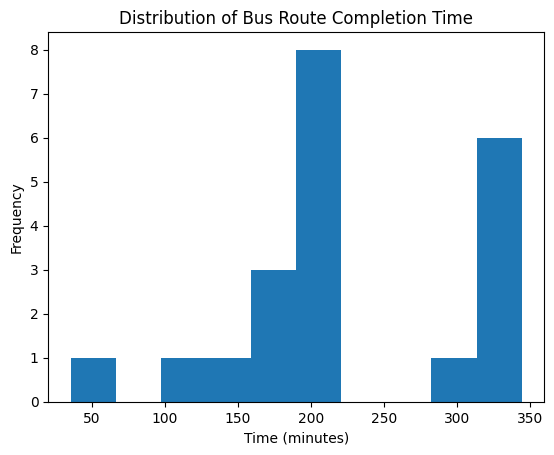

In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(trip_times)
plt.title("Distribution of Bus Route Completion Time")
plt.xlabel("Time (minutes)")
plt.ylabel("Frequency")
plt.show()

<h1>Give an estimate of the speed of the bus from current_stop_sequence = 1 to the last  current_stop_sequence. </h1> 

Note: You can use the haversine Python library to calculate the distance between two points, given two longitude and latitude coordinates.

In [17]:
import numpy as np
import pandas as pd
from haversine import haversine

df['updated_at'] = pd.to_datetime(df['updated_at'])

def compute_speed(group):
    group = group.sort_values('current_stop_sequence')

    # distance along route (stop-to-stop)
    total_distance = 0

    for i in range(1, len(group)):
        prev = (group.iloc[i-1]['latitude'], group.iloc[i-1]['longitude'])
        curr = (group.iloc[i]['latitude'], group.iloc[i]['longitude'])
        total_distance += haversine(prev, curr)

    # time difference (first to last stop)
    time_hours = (
        group['updated_at'].max() - group['updated_at'].min()
    ).total_seconds() / 3600

    if time_hours <= 0:
        return np.nan

    return total_distance / time_hours

speed = df.groupby('trip_id').apply(compute_speed)

print("Average bus speed (km/h):", speed.mean())

Average bus speed (km/h): 10.402934391544248
